# 5. 레이블이 없는 데이터를 활용한 사전 훈련
이제 훈련 함수를 만들고 LLM을 사전 훈련할 차례이다. 생성된 텍스트의 품질을 평가하기 위해 기본적인 모델 평가 기법을 알아보자. 또한 사전 훈련된 가중치를 로드하는 방법을 배운다. 이 가중치가 LLM을 미세튜닝하기 위한 출발점이 된다.

## 5.1 텍스트 생성 모델 평가하기
4장에서 배운 텍스트 생성 과정을 간략히 정리한 후 텍스트 생성을 위해 LLM을 준비한다. 이어서 생성된 텍스트의 품질을 평가하는 기본적인 방법을 소개한다. 그런 다음 훈련 손실과 검증 손실을 계산한다.

### 5.1.1 GPT를 사용해 텍스트 생성하기
GPTModel 클래스와 GPT_CONFIG_124M 딕셔너리를 사용해 GPT 모델을 초기화한다.

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/LLM
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
출력 크기: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
평균:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
분산:

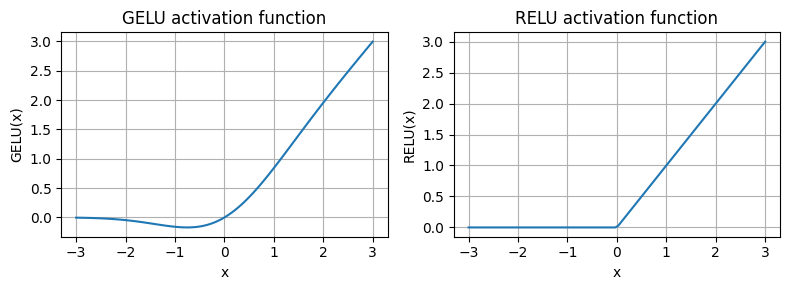

torch.Size([2, 3, 768])
layers.0.0.weight의 평균 그레이디언트는 0.00020173584925942123입니다.
layers.1.0.weight의 평균 그레이디언트는 0.00012011159560643137입니다.
layers.2.0.weight의 평균 그레이디언트는 0.0007152040489017963입니다.
layers.3.0.weight의 평균 그레이디언트는 0.0013988736318424344입니다.
layers.4.0.weight의 평균 그레이디언트는 0.005049645435065031입니다.
layers.0.0.weight의 평균 그레이디언트는 0.22169792652130127입니다.
layers.1.0.weight의 평균 그레이디언트는 0.20694108307361603입니다.
layers.2.0.weight의 평균 그레이디언트는 0.3289699852466583입니다.
layers.3.0.weight의 평균 그레이디언트는 0.2665732204914093입니다.
layers.4.0.weight의 평균 그레이디언트는 1.3258541822433472입니다.
입력 크기: torch.Size([2, 4, 768])
출력 크기: torch.Size([2, 4, 768])
입력 배치:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

출력 크기: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,

In [1]:
from google.colab import drive
drive.mount("/content/drive")

%cd "/content/drive/MyDrive/Colab Notebooks/LLM"
%run "./ch04_implementing_a_GPT_model.ipynb"

In [3]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256, # 문맥 길이를 1,024에서 256으로 줄인다
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

GPTModel의 인스턴스 객체를 4장의 generate_text_simple 함수에 적용하고 2개의 유틸리티 함수 text_to_token_ids와 token_ids_to_text를 만든다. 이 함수들은 이 장에서 활용할 텍스트와 토큰 표현 사이의 변환을 수행한다.

In [4]:
import tiktoken

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 배치 차원 추가
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # 배치 차원 제거
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size = GPT_CONFIG_124M["context_length"]
)
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


이 모델은 훈련되지 않았기 때문에 일관성 있는 텍스트를 만들지 못한다. '일관성이 있는' 텍스트나 '높은 품질의' 텍스트를 정의하려면 생성된 콘텐츠를 평가하기 위한 정량적인 방법이 있어야 한다. 이를 통해 훈련 과정에서 모델의 성능을 모니터링하고 향상시킬 수 있다. 다음 절에서 생성된 출력에 대한 손실을 계산한다. 이 손실은 훈련이 잘 진행되고 있는지 판단하는 성공 지표로 사용된다. 이후 장에서는 LLM을 미세 튜닝할 때 모델 품질을 평가하는 방법을 알아본다.

### 5.1.2 텍스트 생성 손실 계산하기
텍스트 생성 손실(text generate loss)을 계산하여 훈련 과정에서 생성된 텍스트 품질을 정량적으로 평가하는 기법을 알아보자.

2개의 입력 샘플("every efforts moves"와 "I really like")을 미리 토큰 ID로 매핑해놓자.


In [5]:
inputs = torch.tensor([[16833, 3626, 6100], # every efforts moves
                       [40, 1107, 588]]) # I really like

# 입력에 대응하는 targets는 모델이 생성할 토큰 ID를 담고 있다
targets = torch.tensor([[3626, 6100, 345], # effort moves you
                        [1107, 588, 11311]]) # really like chocolate

targets는 한 위치 앞으로 이동한 입력이다.

입력을 모델에 주입하고 각각 3개의 토큰으로 구성된 입력 샘플 2개에 대한 로짓 벡터를 계산해보자. 그런 다음 softmax 함수를 적용해 로짓을 확률 점수(probas)로 변환한다.

In [6]:
with torch.no_grad(): # 아직 훈련하지 않기 때문에 그레이디언트 추적을 끈다
  logits = model(inputs)
probas = torch.softmax(logits, dim=-1) # 어휘사전의 각 토큰에 대한 확률
print(probas.shape)

torch.Size([2, 3, 50257])


확률 점수 텐서(probas)의 차원은 다음과 같다.

확률 점수에 argmax 함수를 적용해 토큰 ID를 추출한다.

In [7]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("토큰 ID:\n", token_ids)

토큰 ID:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


배치에 샘플이 2개이고, 각각 3개의 토큰이 있으므로 argmax 함수를 확률 점수에 적용하면 두 벌의 출력이 나온다. 각 출력은 예측한 3개의 토큰 ID를 담고 있다.

마지막으로 토큰 ID를 텍스트로 변환한다.

In [8]:
print(f"첫 번째 샘플의 타깃: {token_ids_to_text(targets[0], tokenizer)}")
print(f"첫 번째 샘플의 출력: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

첫 번째 샘플의 타깃:  effort moves you
첫 번째 샘플의 출력:  Armed heNetflix


이 모델은 아직 훈련하지 않았기 때문에 타깃 텍스트와 다른 랜덤한 텍스트를 생성한다.

다음 코드로 2개의 입력 텍스트에 대해 타깃 토큰에 해당하는 초기 softmax 확률 점수를 출력한다.

In [9]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("텍스트 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("텍스트 2:", target_probas_2)

텍스트 1: tensor([0.0001, 0.0000, 0.0000])
텍스트 2: tensor([0.0000, 0.0001, 0.0000])


LLM 훈련의 목표는 정답 토큰의 가능성을 최대화하는 것이다. 따라서 다른 토큰에 비해 정답 토큰의 확률을 높여야 한다.

손실을 계산하기 위한 단계이다.
1. 로짓
2. 확률
3. 타깃 토큰 확률
4. 로그 확률
5. 평균 로그 확률
6. 음의 평균 로그 확률

다음으로 두 샘플의 확률 점수 target_probas_1과 target_probas_2에 대한 손실을 계산한다.

target_probas_1과 target_probas_2를 얻기 위해 1~3단계까지 이미 수행했기 때문에 확률 점수에 로그를 적용하는 4단계를 진행한다.

In [10]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


확률 점수에 로그를 적용하면 점수를 그대로 사용하는 것보다 수학적 최적화 과정에서 다루기 쉽다.

이 로그 확률을 평균하여 하나의 점수로 만든다.

In [11]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


출력된 평균 로그 확률은 다음과 같다.

훈련 과정에서 모델의 가중치를 업데이트하여 평균 로그 확률이 가능한 0에 가깝게 만드는 것이 목표이다. 하지만 딥러닝에서는 일반적으로 평균 로그 확률을 0으로 만드는 것보다 음의 평균 로그 확률을 0으로 만든다. 음의 평균 로그 확률은 단순히 평균 로그 확률에 -1을 곱한 값이다. 이 단계가 6단계이다.

In [12]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


이것을 크로스 엔트로피 손실이라 한다. 파이토치는 여섯 단계를 모두 처리하는 cross_entropy 함수를 기본으로 제공한다.

cross_entropy 함수를 적용하기 전에 로짓과 타깃 텐서의 크기를 간략히 확인해 보자.

In [13]:
print("로짓 크기:", logits.shape)
print("타깃 크기:", targets.shape)

로짓 크기: torch.Size([2, 3, 50257])
타깃 크기: torch.Size([2, 3])


여기서 보듯이 logits 텐서는 3개의 차원을 가진다. 각각 배치 크기, 토큰 개수, 어휘사전 크기이다. targets 텐서는 배치 크기와 토큰 개수에 해당하는 2개의 차원을 가진다.

파이토치의 cross_entropy 손실 함수를 위해 처음 두 차원을 결합하여 두 텐서를 펼쳐야 한다.

In [14]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("펼친 로짓:", logits_flat.shape)
print("펼친 타깃:", targets_flat.shape)

펼친 로짓: torch.Size([6, 50257])
펼친 타깃: torch.Size([6])


targets는 모델이 생성하길 기대하는 토큰 ID이다. logits는 확률 점수를 얻기 위해 softmax 함수로 들어가기 전의 정규화되지 않은 모델 출력을 담고 있다.

이전에는 softmax 함수를 적용하고, 타깃 ID에 해당하는 확률 점수를 선택하여 음의 평균 로그 확률을 계산했다. 파이토치의 cross_entropy 함수는 이런 단계를 모두 자동으로 수행한다.

In [15]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


설명을 위해 2개의 텍스트 입력에 대한 손실을 계산했다. 이제 전체 훈련 세트와 검증 세트에 이 손실 계산을 적용한다.

### 5.1.3 훈련 세트와 검증 세트의 손실 계산하기
훈련 세트와 검증 세트의 손실을 계산하기 위해 2장에서 사용했던 "The Verdict"를 사용한다.

In [16]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rickiepark/"
    "llm-from-scratch/main/ch02/01_main-chapter-code/"
    "the-verdict.txt"
)

file_path = "/content/the-verdict.txt"

urllib.request.urlretrieve(url, file_path)

with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("문자 수:", total_characters)
print("토큰 수:", total_tokens)

문자 수: 20479
토큰 수: 5145


그런 다음 데이터셋을 훈련 세트와 검증 세트로 나누고, 2장의 데이터 로더를 사용해 LLM 훈련을 위한 배치를 준비한다.

데이터 분할과 로딩을 구현하기 위해 train_ratio를 0.9로 지정하여 모델 훈련에 데이터의 90%를 사용하고 남은 10%를 평가를 위한 검증 세트로 사용한다.

In [17]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [18]:
from google.colab import drive

drive.mount("/content/drive")

%cd "/content/drive/MyDrive/Colab Notebooks/LLM"

%run "./ch02_working_with_text_data.ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/LLM
총 문자 개수: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
4690
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']
1130
('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon'

In [19]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [20]:
print("훈련 데이터 로더:")
for x, y in train_loader:
  print(x.shape, y.shape)

print("\n검증 데이터 로더:")
for x, y in val_loader:
  print(x.shape, y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


앞의 출력을 보면 9개의 훈련 세트 배치가 있다. 각 배치에는 2개의 샘플이 있고, 각 샘플은 256개의 토큰으로 구성된다. 데이터의 10%만 검증 세트로 할애했기 때문에 검증 세트 배치가 하나뿐이며, 샘플 2개로 구성된다.

그런 다음 훈련 데이터 로더와 검증 데이터 로더가 반환한 배치로 크로스 엔트로피 손실을 계산하는 유틸리티 함수를 구현한다.

In [21]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(
      logits.flatten(0, 1), target_batch.flatten()
  )
  return loss

하나의 배치에 대한 손실을 계산하는 calc_loss_batch 함수를 사용하여 다음에 등장하는 calc_loss_loader를 구현할 수 있다. 이 함수는 데이터 로더가 반환하는 모든 배치에 대한 손실을 계산한다.

In [22]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader) # num_batches가 지정되지 않으면 모든 배치를 순회한다
  else:
    num_batches = min(num_batches, len(data_loader)) # num_batches가 데이터 로더에 있는 배치 개수보다 크면 배치 횟수를 데이터 로더에 있는 총 배치 개수로 맞춘다.
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      total_loss += loss.item() # 각 배치의 손실을 더한다
    else:
      break
  return total_loss / num_batches # 모든 배치의 손실을 평균한다
